In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Resampling library for handling imbalanced data
from imblearn.over_sampling import SMOTE

# Deep learning library for building neural networks
from keras.callbacks import EarlyStopping

# Encoding libraries for transforming categorical data
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# Libraries for splitting data and evaluating model performance
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# Scaling libraries for normalizing numerical data
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Machine learning library for building decision trees
from sklearn.ensemble import RandomForestRegressor

# Regular expression library for text processing
import re

In [3]:
df=pd.read_csv("C:\\Users\\acer\\Downloads\\car_price_prediction.csv.zip")

In [4]:
df.columns=df.columns.str.lower()

In [5]:
df.head()

,id,price,levy,manufacturer,model,prod. year,category,leather interior,fuel type,engine volume,mileage,cylinders,gear box type,drive wheels,doors,wheel,color,airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [6]:
df.describe()

,id,price,prod. year,cylinders,airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                19237 non-null  int64  
 1   price             19237 non-null  int64  
 2   levy              19237 non-null  object 
 3   manufacturer      19237 non-null  object 
 4   model             19237 non-null  object 
 5   prod. year        19237 non-null  int64  
 6   category          19237 non-null  object 
 7   leather interior  19237 non-null  object 
 8   fuel type         19237 non-null  object 
 9   engine volume     19237 non-null  object 
 10  mileage           19237 non-null  object 
 11  cylinders         19237 non-null  float64
 12  gear box type     19237 non-null  object 
 13  drive wheels      19237 non-null  object 
 14  doors             19237 non-null  object 
 15  wheel             19237 non-null  object 
 16  color             19237 non-null  object

In [8]:
df.drop_duplicates(keep='first')
# Dropping the 'id' column from the dataset
df.drop('id',axis=1,inplace=True)


In [9]:
def cat_plot(col,df):
    sns.catplot(x=col,data=df,kind='count',aspect=2,height=5)
    plt.xticks(rotation=90,horizontalalignment='center',fontweight='light',fontsize='x-large',fontstyle='normal')
  

In [10]:
df['turpocharged']=df['engine volume'].apply(lambda x: 1 if 'Turbo' in x else 0)
# Extracting the numerical value from the 'engine volume' column and converting it to float
df['engine volume']=df['engine volume'].apply(lambda x: re.findall(r'\d+\.?\d*',x)[0]).sort_values().astype(float)
# Converting '-' in the 'levy' column to NaN and converting all values to float
df['levy']=df['levy'].apply(lambda x: np.nan if '-' in x else x).astype(float)
# Extracting the numerical value from the 'mileage' column and converting it to float
df['mileage']=df['mileage'].apply(lambda x: re.findall(r'\d+\.?\d*',x)[0]).sort_values().astype(float)
# Extracting the numerical value from the 'doors' column and converting it to float
df['doors']=df['doors'].apply(lambda x: re.findall(r'\d+',x)[0]).sort_values().astype(float)
# Replacing all occurrences of 5 with 4 in the 'doors'
df['doors']=df['doors'].replace(5,4)


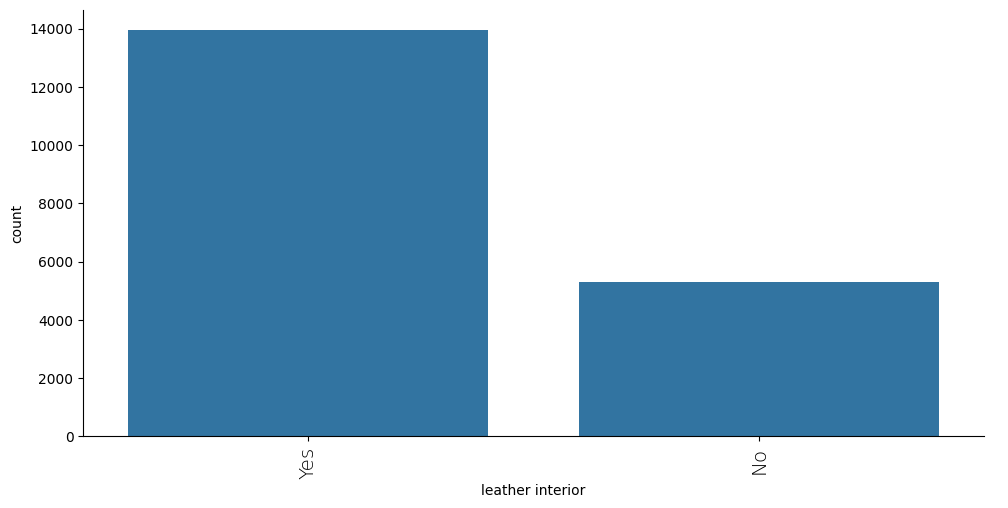

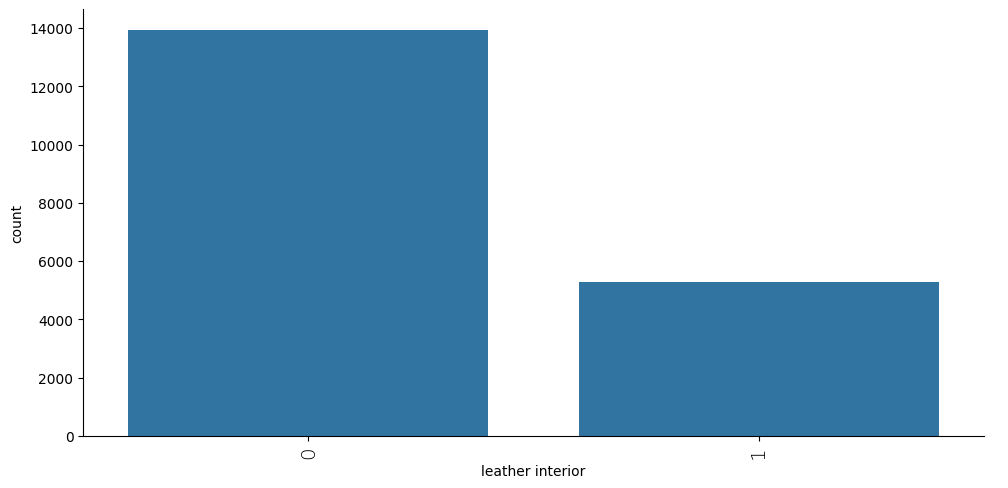

In [11]:
cat_plot('leather interior',df)
df['leather interior']=df['leather interior'].apply(lambda x:0 if'Yes'in x else 1)
cat_plot('leather interior',df)

In [12]:
df['car_value']=df['price'].apply(lambda x:1 if x>20000 else 0)

In [13]:
def mapping_unique(col,df):
    """
    Create a dictionary that maps unique values in a column of a DataFrame to unique integer values starting from 1.
    
    Parameters:
    col (str): Name of the column to map.
    df (pandas.DataFrame): DataFrame containing the column to map.
    
    Returns:
    dict: A dictionary that maps unique values in the column to unique integer values starting from 1.
    """
   # Initialize an empty dictionary to store the mapping
    mapping = {}
    
    # Initialize a counter to generate unique integer values
    count = 0
    
    # Loop over unique values in the column
    for i in df[col].unique():
        # Map the value to the next integer value
        mapping[i] = count + 1
        
        # Increment the counter
        count += 1
    
    # Return the mapping dictionary
    return mapping
def transform_unique(col,df):
    """
    Transform a column of a DataFrame by mapping unique values to unique integer values starting from 1.
    
    Parameters:
    col (str): Name of the column to transform.
    df (pandas.DataFrame): DataFrame containing the column to transform.
    
    Returns:
    pandas.Series: A Series containing the transformed column.
    """
    # Create a mapping dictionary for the column
    mapping = mapping_unique(col, df)
    
    # Map the values in the column to the integer values using the mapping dictionary
    df[col] = df[col].map(mapping)
    
    # Return the transformed column as a Series
    return df[col]

In [14]:
df['gear box type'] = transform_unique('gear box type', df)

# Transform the 'model' column
df['model'] = transform_unique('model', df)

# Transform the 'fuel type' column
df['fuel type'] = transform_unique('fuel type', df)

# Transform the 'manufacturer' column
df['manufacturer'] = transform_unique('manufacturer', df)

# Transform the 'category' column
df['category'] = transform_unique('category', df)

# Transform the 'drive wheels' column
df['drive wheels'] = transform_unique('drive wheels', df)

# Transform the 'color' column
df['color'] = transform_unique('color', df)

# Transform the 'wheel' column
df['wheel'] = transform_unique('wheel', df)

<Axes: >

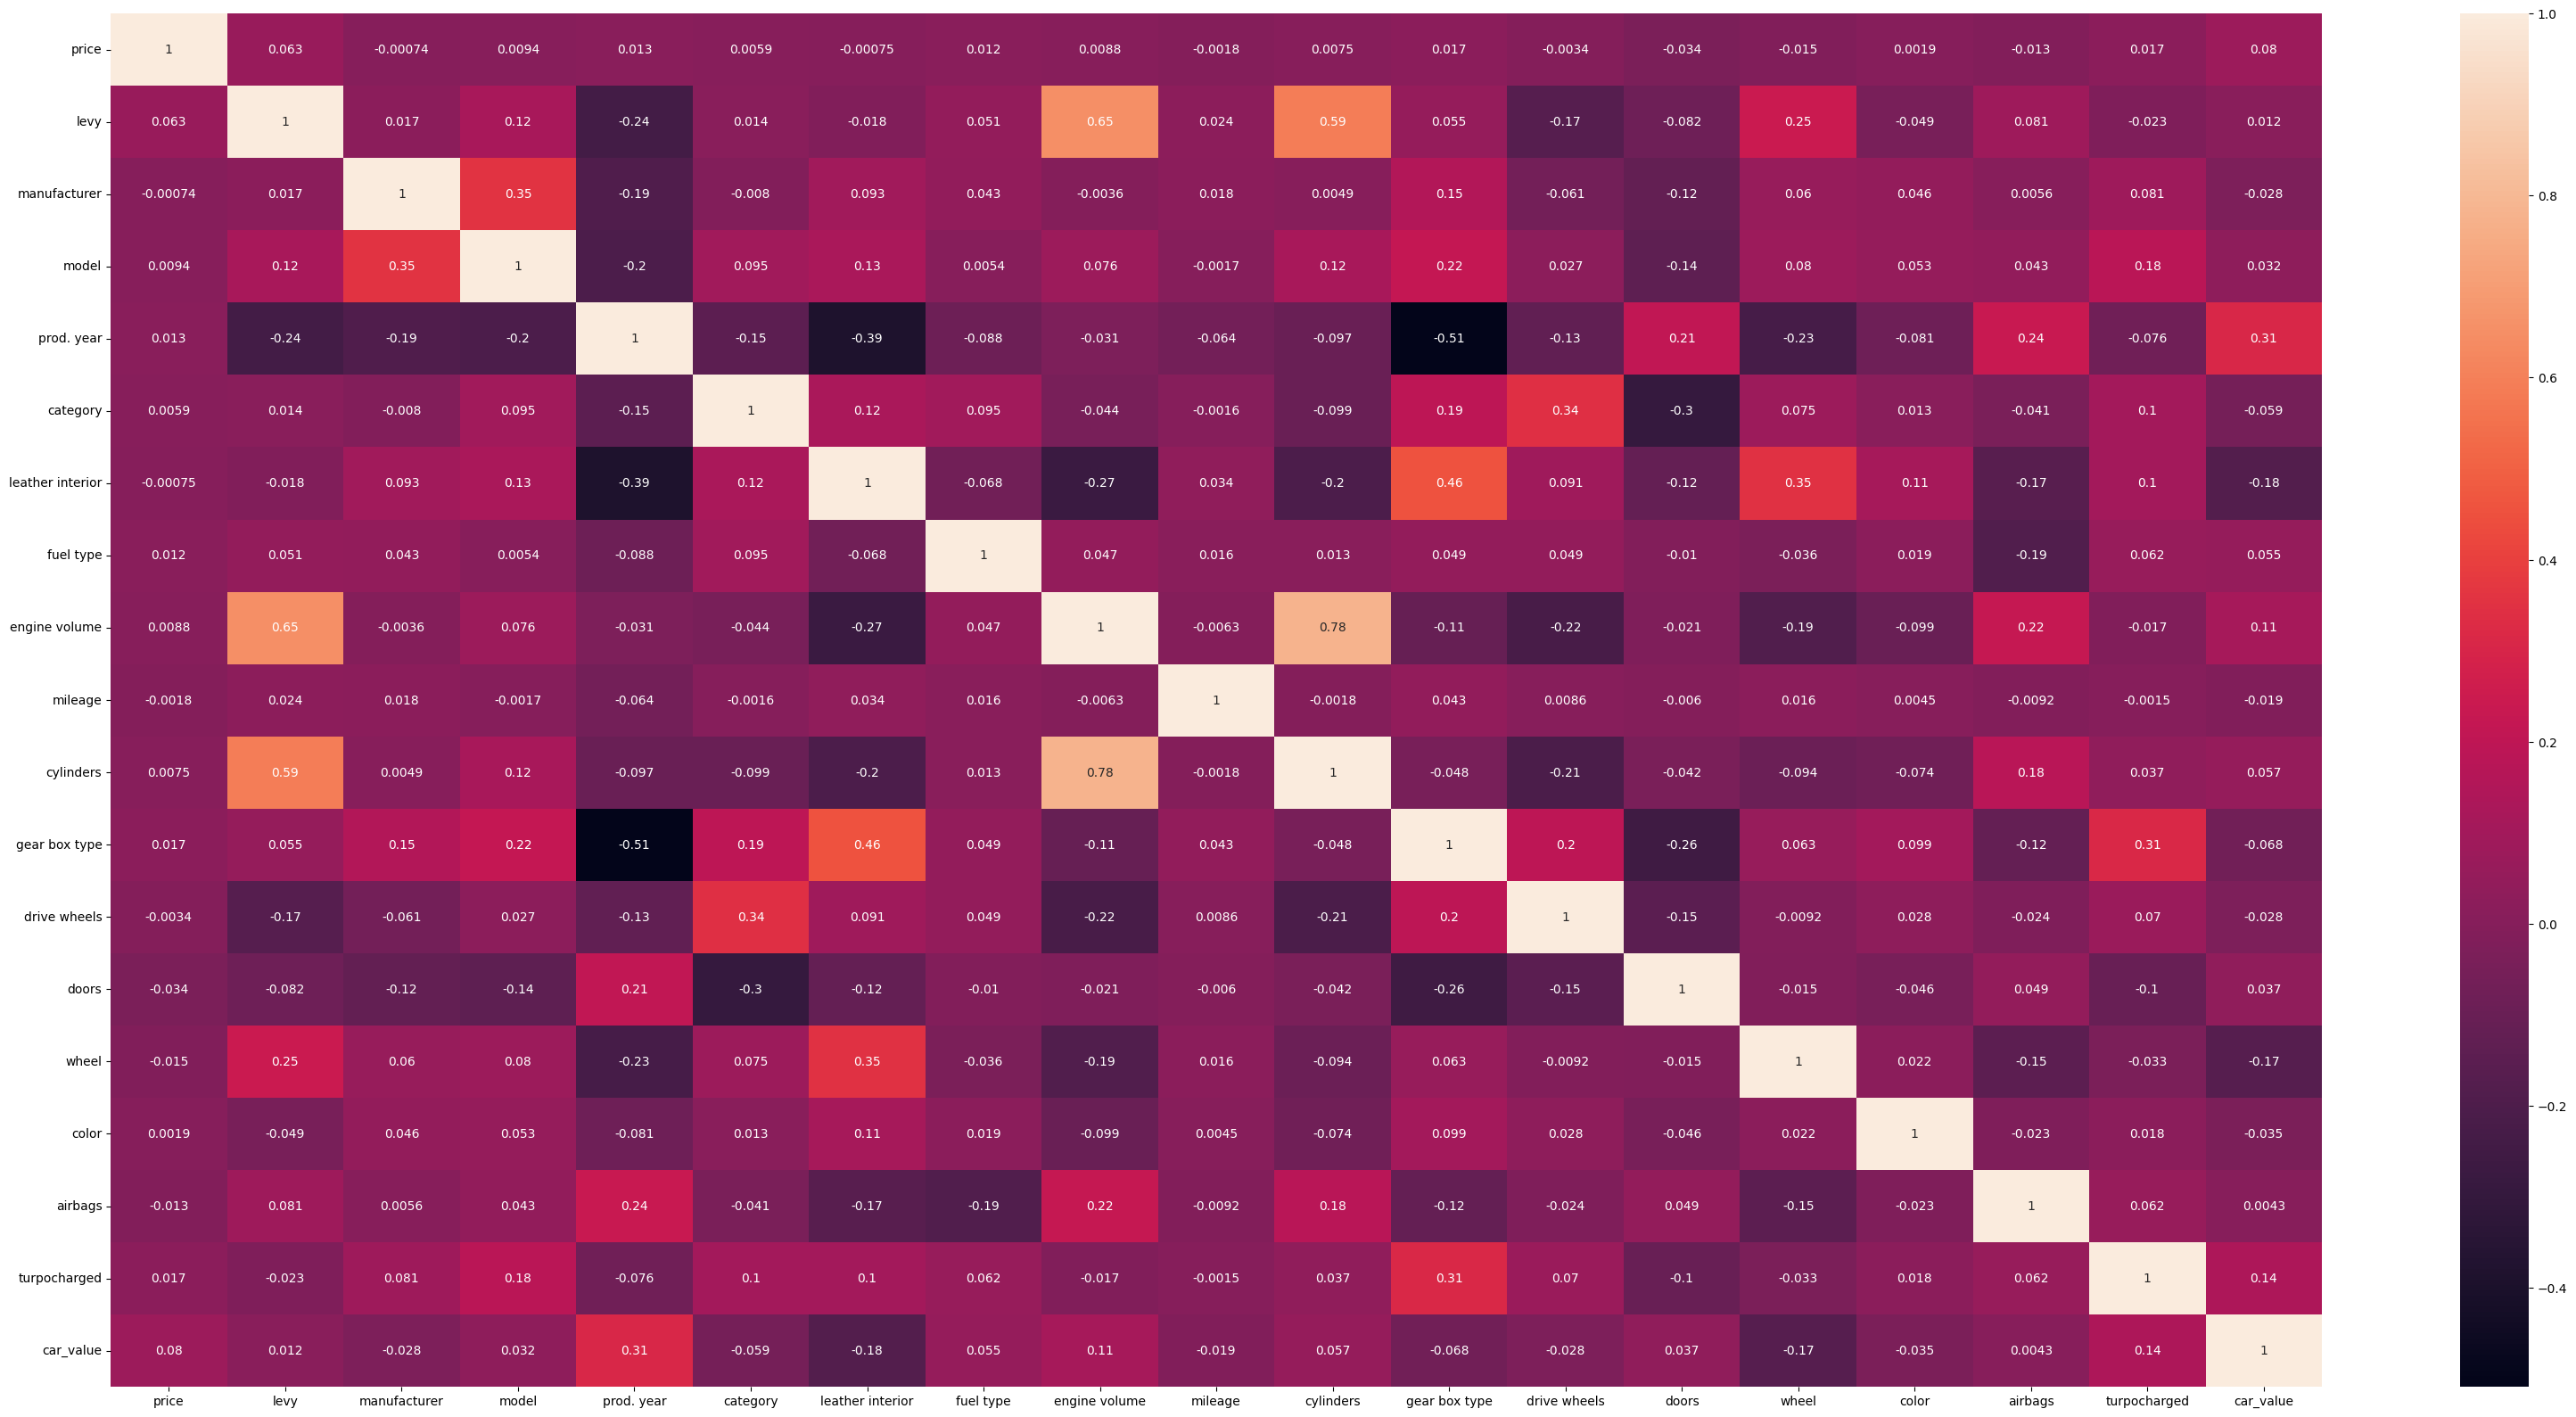

In [15]:
plt.figure(figsize=(40,20))
sns.heatmap(df.corr(),annot=True)

In [16]:
df.describe()

,price,levy,manufacturer,model,prod. year,category,leather interior,fuel type,engine volume,mileage,cylinders,gear box type,drive wheels,doors,wheel,color,airbags,turpocharged,car_value
count,1.923700e+04,13418.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,1.923700e+04,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.00000
mean,1.855593e+04,906.838128,8.200343,161.474658,2010.912824,2.695535,0.274627,2.274315,2.307990,1.532236e+06,4.582991,1.531216,1.908874,3.919218,1.077143,3.304517,6.582627,0.100379,0.29568
std,1.905813e+05,461.867051,6.969671,284.685013,5.668673,1.726214,0.446338,1.098531,0.877805,4.840387e+07,1.199933,0.954695,0.567875,0.393759,0.266825,2.555601,4.320168,0.300513,0.45636
min,1.000000e+00,87.000000,1.000000,1.000000,1939.000000,1.000000,0.000000,1.000000,0.000000,0.000000e+00,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.00000
25%,5.331000e+03,640.000000,5.000000,10.000000,2009.000000,1.000000,0.000000,2.000000,1.800000,7.013900e+04,4.000000,1.000000,2.000000,4.000000,1.000000,2.000000,4.000000,0.000000,0.00000
50%,1.317200e+04,781.000000,6.000000,43.000000,2012.000000,3.000000,0.000000,2.000000,2.000000,1.260000e+05,4.000000,1.000000,2.000000,4.000000,1.000000,3.000000,6.000000,0.000000,0.00000
75%,2.207500e+04,1058.000000,10.000000,163.000000,2015.000000,3.000000,1.000000,3.000000,2.500000,1.888880e+05,4.000000,2.000000,2.000000,4.000000,1.000000,4.000000,12.000000,0.000000,1.00000
max,2.630750e+07,11714.000000,65.000000,1590.000000,2020.000000,11.000000,1.000000,7.000000,20.000000,2.147484e+09,16.000000,4.000000,3.000000,4.000000,2.000000,16.000000,16.000000,1.000000,1.00000


In [17]:
def outliner_removal(col,df):
    q1=df[col].quantile(0.40)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df=df[(df[col]>lower)&(df[col]<upper)]
    print("*"*50)
    print(col)
    print('lower bound',col+':',lower)
    print('upper bound',col+':',upper)
    print("*"*50)
    return df

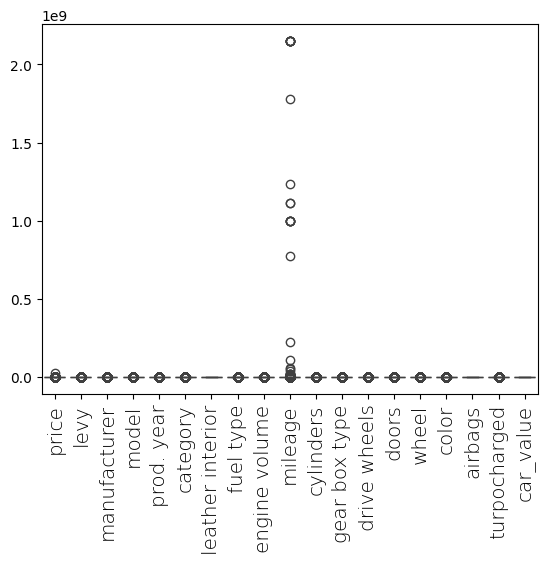

In [18]:
sns.boxplot(data=df)

# Customize the x-axis labels of the plot using matplotlib
plt.xticks(rotation=90, horizontalalignment='center', fontweight='light', fontsize='x-large', fontstyle='normal')

# Display the plot
plt.show()

In [19]:
df = outliner_removal('mileage', df)
# Remove outliers from the 'price' column using the 'outliner_removal' function
df = outliner_removal('price', df)

**************************************************
mileage
lower bound mileage: -18471.49999999997
upper bound mileage: 313303.69999999995
**************************************************
**************************************************
price
lower bound price: -8091.0
upper bound price: 41485.0
**************************************************


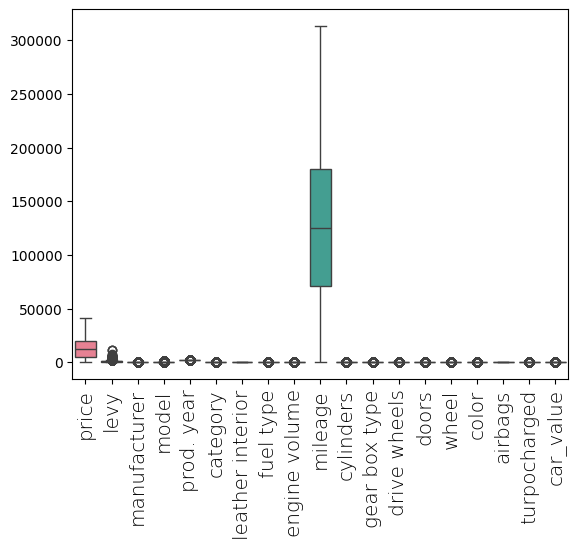

In [20]:
sns.boxplot(data=df)

# Customize the x-axis labels of the plot using matplotlib
plt.xticks(rotation=90, horizontalalignment='center', fontweight='light', fontsize='x-large', fontstyle='normal')

# Display the plot
plt.show()

In [21]:
df.dropna(axis=0,inplace=True)

In [22]:
x = df.drop(['price', 'cylinders'], axis=1)

# Assign the 'price' column to 'y'
y = df['price']

# Scale the features in 'x' using the MinMaxScaler
ss = MinMaxScaler()
x_s = ss.fit_transform(x)

# Split the data into training and testing sets using train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_s, y, test_size=0.2, random_state=42)

In [23]:
model = RandomForestRegressor()

# Fit the model to the training data
model.fit(x_train, y_train)

# Use the model to predict the target variable for the testing data
y_pred = model.predict(x_test)

# Use the model to predict the target variable for the training data
y_tpred = model.predict(x_train)

# Calculate the mean squared error for the training data and testing data
mean_train = mean_squared_error(y_train, y_tpred)
mean_test = mean_squared_error(y_test, y_pred)

# Calculate the square root of the mean squared error for the testing data and training data
forest_sqrt = np.sqrt(mean_test)
forest_sqrt_tr = np.sqrt(mean_train)
r2_train = r2_score(y_train, y_tpred)
r2_test = r2_score(y_test, y_pred)

# Print the evaluation metrics for the model
print('Random Forest Regression Model Evaluation\n')
print(f'Root Mean Squared Error (Training): {forest_sqrt_tr:.2f}')
print(f'Root Mean Squared Error (Testing): {forest_sqrt:.2f}\n')
print(f'R-squared Score (Training): {r2_train:.2f}')
print(f'R-squared Score (Testing): {r2_test:.2f}')

Random Forest Regression Model Evaluation

Root Mean Squared Error (Training): 1299.09
Root Mean Squared Error (Testing): 3209.86

R-squared Score (Training): 0.99
R-squared Score (Testing): 0.91


In [24]:
feature_df=pd.DataFrame({'feature':x.columns,'importance':model.feature_importances_})
feature_df.sort_values(by='importance',ascending=False)
feature_df.head(10)

,feature,importance
0,levy,0.022327
1,manufacturer,0.014136
2,model,0.023333
3,prod. year,0.034151
4,category,0.007790
5,leather interior,0.019623
6,fuel type,0.013043
7,engine volume,0.018322
8,mileage,0.047610
9,gear box type,0.024889
